In [1]:
!pip install transformers torch datasets gradio pandas scikit-learn seaborn matplotlib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
print("All libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

All libraries loaded successfully!
PyTorch version: 2.10.0+cu128
GPU available: True


In [3]:
from google.colab import files
uploaded = files.upload()

Saving Combined Data.csv to Combined Data.csv


In [4]:
df = pd.read_csv('Combined Data.csv')
print(df.columns.tolist())
print(df['status'].value_counts())

['Unnamed: 0', 'statement', 'status']
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'text': [
        # Normal (label 0)
        "I'm feeling great today, had a wonderful time",
        "Life is beautiful, I'm so grateful for everything",
        "Just had the best day with my friends!",
        "I'm so happy, got my dream job today!",
        "Today was productive, feeling accomplished",
        "Life is good, spending time with family today",
        "Had an amazing workout, feeling energetic!",
        "Enjoying a peaceful evening with a good book",
        "Just finished my project, feeling proud!",
        "Feeling motivated and ready to take on the day!",
        "Had a great meal and lovely conversation today",
        "Feeling calm and content, life is good",

        # Mild Stress (label 1)
        "Feeling a bit stressed about exams but okay",
        "Stressed but managing, just need a break",
        "A little overwhelmed with deadlines but coping",
        "Work is piling up but I'll get through it",
        "Tired after a long day, need some rest",
        "Feeling pressure but staying positive",
        "Exams are near, a bit nervous but prepared",
        "Slightly anxious about tomorrow's presentation",
        "Need a vacation, feeling burnt out slightly",
        "Bit worried about results but staying calm",
        "Managing stress with exercise and good sleep",
        "Feeling tense but in control of things",

        # Anxiety (label 2)
        "Everything is overwhelming, I can't handle this",
        "I had a panic attack again this morning",
        "I haven't slept in days, my mind won't stop",
        "Anxiety is hitting hard today, can't focus at all",
        "My heart is racing, feeling very anxious",
        "The anxiety won't let me breathe properly",
        "Constant worry is ruining my daily life",
        "I feel paralyzed by fear and anxiety",
        "My hands won't stop shaking from nervousness",
        "Panic attacks are becoming more frequent now",
        "I can't leave the house, anxiety is too bad",
        "Racing thoughts keeping me awake every night",

        # Depression (label 3)
        "I feel so hopeless, nothing matters anymore",
        "I can't stop crying and I don't know why",
        "I feel empty inside, like nothing will ever improve",
        "Feeling really low, don't want to talk to anyone",
        "Can't get out of bed, everything feels pointless",
        "I cried myself to sleep again last night",
        "I feel like a burden to everyone around me",
        "Nothing brings me joy anymore, I'm so tired",
        "I am worthless and nobody cares about me",
        "Lost all interest in things I used to love",
        "Darkness surrounds me, no hope for tomorrow",
        "Every day feels the same, empty and meaningless",

        # Crisis (label 4)
        "I don't want to be here anymore",
        "I think about ending it all sometimes",
        "I keep having dark thoughts I can't control",
        "I've been thinking about hurting myself",
        "Can't see any reason to continue living",
        "I feel like disappearing from this world forever",
        "Nobody would miss me if I was gone",
        "The pain is unbearable, I see no way out",
        "I have a plan to end everything tonight",
        "Life has no meaning, I want it to stop",
        "Thinking of suicide every single day now",
        "I just want the pain to end permanently",
    ],
    'label': [
        0,0,0,0,0,0,0,0,0,0,0,0,  # Normal
        1,1,1,1,1,1,1,1,1,1,1,1,  # Mild Stress
        2,2,2,2,2,2,2,2,2,2,2,2,  # Anxiety
        3,3,3,3,3,3,3,3,3,3,3,3,  # Depression
        4,4,4,4,4,4,4,4,4,4,4,4   # Crisis
    ]
}

label_names = {0:'Normal', 1:'Mild Stress', 2:'Anxiety',
               3:'Depression', 4:'Crisis'}

df = pd.DataFrame(data)
df['label_name'] = df['label'].map(label_names)

print("✅ Dataset ready!")
print(f"Total samples: {len(df)}")
print("\nDistress level counts:")
print(df['label_name'].value_counts())

✅ Dataset ready!
Total samples: 60

Distress level counts:
label_name
Normal         12
Mild Stress    12
Anxiety        12
Depression     12
Crisis         12
Name: count, dtype: int64


In [6]:
paragraph_data = {
    'text': [
        # Normal paragraphs
        "Today was such a wonderful day. I woke up feeling refreshed and had a great breakfast. Met my friends in the evening and we laughed so much. Life feels really good right now and I am grateful for everything.",
        "I just finished my exams and I think they went really well. My family is proud of me and I feel so accomplished. Looking forward to the holidays and spending time with people I love.",
        "Had the most productive day today. Finished all my pending work, exercised in the morning, cooked a healthy meal. Feeling very positive and motivated about life right now.",

        # Mild stress paragraphs
        "I have so many assignments due this week and I am finding it hard to manage my time. I know I will get through it but right now I feel a bit overwhelmed. Just need to take it one day at a time and stay focused.",
        "Work has been really hectic lately. My boss keeps adding more tasks and I feel like I cannot keep up. I am tired but I know this phase will pass. Just need to push through the next few days.",
        "I have been feeling a bit nervous about my upcoming presentation. I have prepared well but still feel some butterflies. I think once I start speaking it will be fine but the anxiety before is real.",

        # Anxiety paragraphs
        "I woke up today with my heart racing and I do not even know why. The anxiety has been so bad lately that I cannot focus on anything. Every small thing feels like a huge threat. I keep thinking something terrible is going to happen and I cannot make it stop.",
        "I have been having panic attacks almost every day now. They come out of nowhere and I feel like I am dying. My chest gets tight I cannot breathe and I shake uncontrollably. I am scared to go out because I do not know when the next one will hit.",
        "The anxiety is completely ruining my life. I cannot sleep properly cannot eat properly and cannot focus at work. My mind is constantly racing with worst case scenarios. I feel trapped inside my own head and I do not know how to escape.",

        # Depression paragraphs
        "I have not been able to get out of bed for three days now. Everything feels completely pointless and I do not see the purpose in doing anything. I used to love painting but even that brings me no joy anymore. I feel empty and hollow inside like a shell of who I used to be.",
        "I have been feeling really low for months now. Nothing excites me anymore and I feel completely disconnected from the world. I go through the motions every day but I feel nothing inside. I cry for no reason and I am exhausted all the time. I do not know how much longer I can keep going like this.",
        "Depression has taken everything from me. My relationships my hobbies my motivation my happiness. I wake up every morning feeling heavy and dread facing another day. I feel like a burden to everyone around me and I honestly do not see things getting better.",

        # Crisis paragraphs
        "I have been thinking about ending my life for weeks now. The pain is just too much and I cannot see any way out. I have tried to get better but nothing works. I am so tired of fighting every single day. I do not want to be here anymore and I am starting to make plans.",
        "I cannot take this anymore. Every single day is unbearable and I see absolutely no point in continuing. I have thought about this carefully and I believe everyone would be better off without me. I have been saying goodbye to people slowly and I feel strangely calm about my decision.",
        "The suicidal thoughts are constant now. I think about it every hour of every day. I have even started looking up methods because I am serious about this. I feel completely hopeless and I genuinely believe this is the only way to make the pain stop permanently.",
    ],
    'label': [0,0,0, 1,1,1, 2,2,2, 3,3,3, 4,4,4]
}

df_para = pd.DataFrame(paragraph_data)
df_para['label_name'] = df_para['label'].map(label_names)

# Combine with existing dataset
df = pd.concat([df, df_para], ignore_index=True)
print(f"Combined dataset: {len(df)} samples")
print(df['label_name'].value_counts())

Combined dataset: 75 samples
label_name
Normal         15
Mild Stress    15
Anxiety        15
Depression     15
Crisis         15
Name: count, dtype: int64


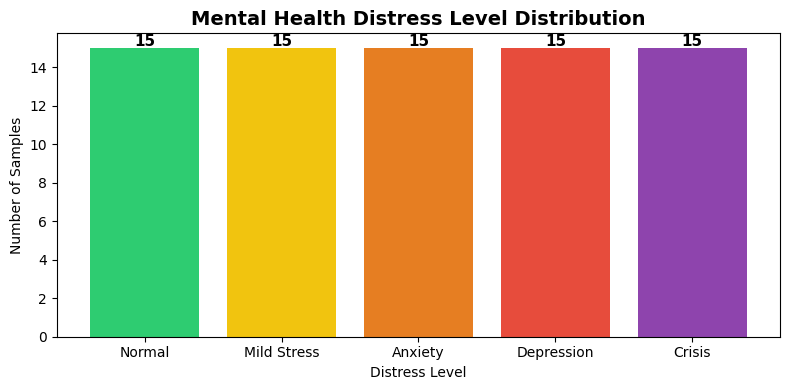

✅ Day 1 Complete! 60 samples across 5 distress levels.


In [7]:
colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C', '#8E44AD']
plt.figure(figsize=(8, 4))
counts = df['label_name'].value_counts()
ordered = ['Normal','Mild Stress','Anxiety','Depression','Crisis']
vals = [counts[l] for l in ordered]
bars = plt.bar(ordered, vals, color=colors)
plt.title('Mental Health Distress Level Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Distress Level')
plt.ylabel('Number of Samples')
for bar, val in zip(bars, vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Day 1 Complete! 60 samples across 5 distress levels.")

In [8]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-zA-Z\s!?.,]', '', text) # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

print("✅ Text cleaned!")
print("\nBefore vs After cleaning:")
for i in range(3):
    print(f"\nOriginal : {df['text'][i]}")
    print(f"Cleaned  : {df['clean_text'][i]}")

✅ Text cleaned!

Before vs After cleaning:

Original : I'm feeling great today, had a wonderful time
Cleaned  : im feeling great today, had a wonderful time

Original : Life is beautiful, I'm so grateful for everything
Cleaned  : life is beautiful, im so grateful for everything

Original : Just had the best day with my friends!
Cleaned  : just had the best day with my friends!


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # ensures all 5 classes in both splits
)

print("✅ Data split done!")
print(f"Training samples  : {len(X_train)}")
print(f"Testing samples   : {len(X_test)}")

✅ Data split done!
Training samples  : 60
Testing samples   : 15


In [10]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("✅ BERT Tokenizer loaded!")

# Test it on one sentence
sample = "I feel so hopeless and empty inside"
tokens = tokenizer(sample, padding='max_length', max_length=128,
                   truncation=True, return_tensors='pt')

print(f"\nSample sentence : {sample}")
print(f"Input IDs shape : {tokens['input_ids'].shape}")
print(f"Tokens preview  : {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])[:10]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ BERT Tokenizer loaded!

Sample sentence : I feel so hopeless and empty inside
Input IDs shape : torch.Size([1, 128])
Tokens preview  : ['[CLS]', 'i', 'feel', 'so', 'hopeless', 'and', 'empty', 'inside', '[SEP]', '[PAD]']


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            max_length=self.max_len,
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = MentalHealthDataset(X_train, y_train, tokenizer)
test_dataset  = MentalHealthDataset(X_test,  y_test,  tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

print("✅ Dataset and DataLoader ready!")
print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")


✅ Dataset and DataLoader ready!
Train batches : 8
Test batches  : 2


In [12]:
from transformers import BertForSequenceClassification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load BERT with 5 output classes
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=5
)
model = model.to(device)
print("✅ BERT model loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT model loaded successfully!
Model parameters: 109,486,085


In [13]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * 20
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)
print("Optimizer and scheduler ready!")

Optimizer and scheduler ready!


In [14]:
from torch.nn import CrossEntropyLoss

EPOCHS = 20
train_losses = []

print("🚀 Starting BERT training...\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask,
                       labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/20 | Loss: {avg_loss:.4f}")

print("\n✅ Training complete!")

🚀 Starting BERT training...

Epoch  5/20 | Loss: 1.1580
Epoch 10/20 | Loss: 0.6883
Epoch 15/20 | Loss: 0.4255
Epoch 20/20 | Loss: 0.3410

✅ Training complete!


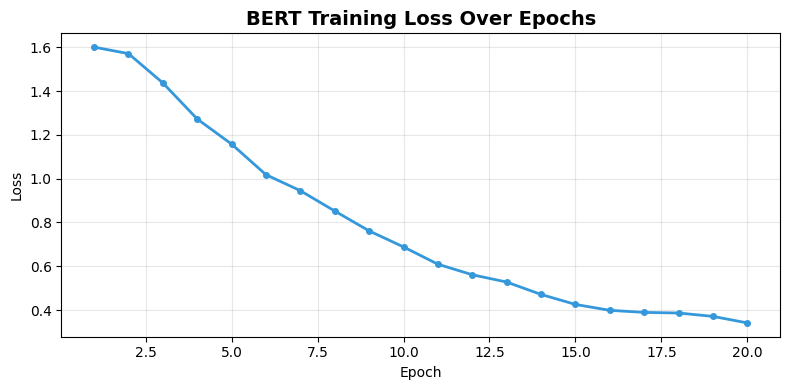

✅ Training loss chart ready — add this to your report!


In [15]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, color='#3498DB', linewidth=2, marker='o', markersize=4)
plt.title('BERT Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Training loss chart ready — add this to your report!")

In [16]:
import os
os.makedirs('/content/mental_health_model', exist_ok=True)
model.save_pretrained('/content/mental_health_model')
tokenizer.save_pretrained('/content/mental_health_model')
print("✅ Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved successfully!


In [17]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions done!")

Predictions done!


In [18]:
from sklearn.metrics import classification_report, accuracy_score

label_list = ['Normal', 'Mild Stress', 'Anxiety', 'Depression', 'Crisis']
accuracy   = accuracy_score(all_labels, all_preds)

print(f"Overall Accuracy: {accuracy*100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=label_list))

Overall Accuracy: 80.00%

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         3
 Mild Stress       1.00      0.67      0.80         3
     Anxiety       0.50      1.00      0.67         3
  Depression       1.00      0.67      0.80         3
      Crisis       1.00      0.67      0.80         3

    accuracy                           0.80        15
   macro avg       0.90      0.80      0.81        15
weighted avg       0.90      0.80      0.81        15



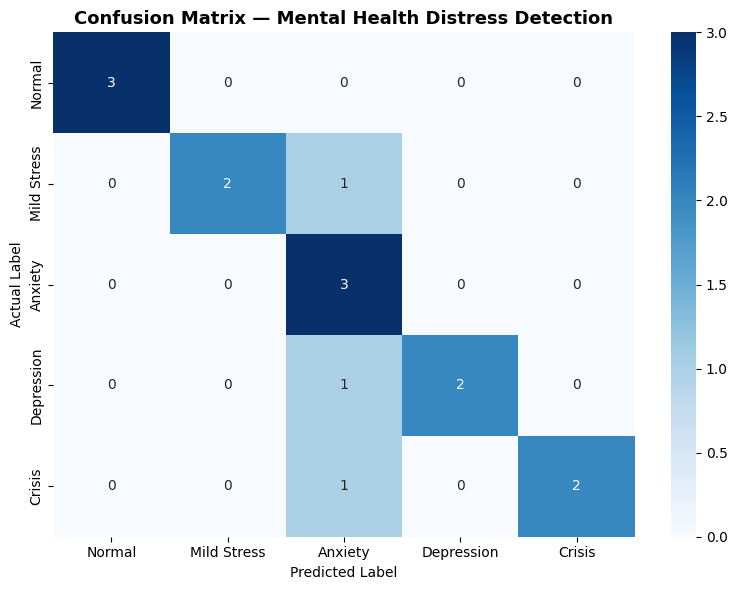

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list,
            yticklabels=label_list)
plt.title('Confusion Matrix — Mental Health Distress Detection',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [20]:
# Compassionate response generator based on distress level
label_names = {0:'Normal', 1:'Mild Stress', 2:'Anxiety',
               3:'Depression', 4:'Crisis'}

responses = {
    0: [
        "You seem to be in a great place! Keep nurturing your positive mindset and wellbeing.",
        "Wonderful! Your positive energy is inspiring. Keep doing what makes you happy!",
        "Great to hear you're doing well! Remember to maintain this balance in life."
    ],
    1: [
        "It sounds like you're under some pressure. Remember to take short breaks and breathe deeply.",
        "Stress is manageable — try breaking your tasks into smaller steps. You've got this!",
        "A little stress is normal. Try some light exercise or talking to a friend today."
    ],
    2: [
        "I can hear that anxiety is weighing heavily on you. Try the 4-7-8 breathing technique — breathe in for 4 seconds, hold for 7, out for 8.",
        "Anxiety can feel overwhelming, but you are not alone. Ground yourself — name 5 things you can see around you right now.",
        "You're dealing with a lot. Please be kind to yourself — consider talking to someone you trust today."
    ],
    3: [
        "I'm really sorry you're feeling this way. Depression is real and you deserve support. Please reach out to someone close to you.",
        "You matter more than you know. These feelings are temporary even when they don't feel like it. Please talk to someone today.",
        "Feeling empty is one of the hardest things. You don't have to face this alone — please consider speaking with a counselor."
    ],
    4: [
        "Please know that you are not alone and your life has tremendous value. Reach out to iCall India: 9152987821 immediately.",
        "You matter deeply. Please contact a crisis helpline right now — iCall: 9152987821. Someone is ready to listen.",
        "This is a difficult moment, but help is available right now. Please call iCall India at 9152987821. You deserve support."
    ]
}

import random

def generate_response(label):
    return random.choice(responses[label])

print("Response generator ready!")
print("\nTest responses:")
for i in range(5):
    print(f"\n{label_names[i]}: {generate_response(i)}")

Response generator ready!

Test responses:

Normal: Great to hear you're doing well! Remember to maintain this balance in life.

Mild Stress: A little stress is normal. Try some light exercise or talking to a friend today.

Anxiety: Anxiety can feel overwhelming, but you are not alone. Ground yourself — name 5 things you can see around you right now.

Depression: I'm really sorry you're feeling this way. Depression is real and you deserve support. Please reach out to someone close to you.

Crisis: Please know that you are not alone and your life has tremendous value. Reach out to iCall India: 9152987821 immediately.


In [21]:
def predict_distress(text):
    clean = clean_text(text)

    # Smart truncation for long paragraphs
    # Keep first 100 and last 28 tokens for long text
    encoding = tokenizer(
        clean,
        padding='max_length',
        max_length=128,        # increased from 64
        truncation=True,
        return_tensors='pt',
        stride=32,             # overlap for long text
        return_overflowing_tokens=False
    )

    model.eval()
    with torch.no_grad():
        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        outputs        = model(input_ids=input_ids,
                               attention_mask=attention_mask)
        probs      = torch.softmax(outputs.logits, dim=1)
        confidence = torch.max(probs).item()
        predicted  = torch.argmax(probs, dim=1).item()

    return {
        'text'      : text,
        'distress'  : label_names[predicted],
        'level'     : predicted,
        'confidence': round(confidence * 100, 2),
        'response'  : generate_response(predicted)
    }

In [22]:
import gradio as gr

def get_level_info(level):
    info = {
        0: {"emoji": "😊", "color": "#00ff88", "glow": "#00ff8844", "label": "Normal", "bar": 5, "grade": "A"},
        1: {"emoji": "😟", "color": "#ffd700", "glow": "#ffd70044", "label": "Mild Stress", "bar": 25, "grade": "B"},
        2: {"emoji": "😰", "color": "#ff8c00", "glow": "#ff8c0044", "label": "Anxiety", "bar": 50, "grade": "C"},
        3: {"emoji": "😢", "color": "#ff4444", "glow": "#ff444444", "label": "Depression", "bar": 75, "grade": "D"},
        4: {"emoji": "🆘", "color": "#cc44ff", "glow": "#cc44ff44", "label": "Crisis", "bar": 100, "grade": "!"},
    }
    return info[level]

def analyze_text(user_text):
    if not user_text.strip():
        return """<div style='display:flex;align-items:center;justify-content:center;
            height:400px;font-family:"Segoe UI",sans-serif'>
            <div style='text-align:center'>
                <div style='font-size:60px;margin-bottom:20px;opacity:0.3'>🧠</div>
                <div style='color:#444;font-size:16px'>Enter text above and click Analyze</div>
            </div></div>""", "", ""

    result = predict_distress(user_text)
    level  = result['level']
    info   = get_level_info(level)
    conf   = result['confidence']
    resp   = result['response']
    words  = len(user_text.split())
    chars  = len(user_text)

    result_html = f"""
<div style='font-family:"Segoe UI",sans-serif'>

  <!-- 3D Glowing Main Card -->
  <div style='
    background:linear-gradient(145deg,#0a0a0f,#12121a);
    border:1px solid {info["color"]}33;
    border-radius:24px;
    padding:32px;
    margin-bottom:16px;
    box-shadow:0 0 40px {info["glow"]},0 20px 60px #00000088,inset 0 1px 0 #ffffff0a;
    position:relative;overflow:hidden'>

    <!-- Animated background orb -->
    <div style='
      position:absolute;top:-60px;right:-60px;
      width:200px;height:200px;border-radius:50%;
      background:radial-gradient(circle,{info["glow"]},transparent 70%);
      animation:pulse 3s ease-in-out infinite'></div>

    <div style='position:relative;z-index:1'>
      <!-- Emoji with glow ring -->
      <div style='text-align:center;margin-bottom:24px'>
        <div style='
          display:inline-flex;align-items:center;justify-content:center;
          width:100px;height:100px;border-radius:50%;
          background:radial-gradient(circle,{info["glow"]},{info["color"]}11);
          border:2px solid {info["color"]}66;
          box-shadow:0 0 30px {info["glow"]},0 0 60px {info["glow"]};
          font-size:52px'>
          {info["emoji"]}
        </div>
      </div>

      <!-- Level label -->
      <div style='text-align:center;margin-bottom:8px'>
        <span style='
          font-size:11px;letter-spacing:4px;text-transform:uppercase;
          color:{info["color"]}99;font-weight:600'>DISTRESS LEVEL</span>
      </div>
      <div style='
        text-align:center;font-size:38px;font-weight:900;
        color:{info["color"]};letter-spacing:2px;margin-bottom:24px;
        text-shadow:0 0 30px {info["color"]}88'>
        {info["label"].upper()}
      </div>

      <!-- Confidence arc display -->
      <div style='
        background:#ffffff08;border-radius:16px;padding:20px;
        margin-bottom:20px;border:1px solid #ffffff0a'>
        <div style='display:flex;justify-content:space-between;
             align-items:center;margin-bottom:12px'>
          <span style='color:#666;font-size:12px;letter-spacing:2px;
               text-transform:uppercase'>CONFIDENCE SCORE</span>
          <span style='color:{info["color"]};font-size:28px;font-weight:800'>
            {conf}%</span>
        </div>
        <div style='
          height:8px;background:#ffffff0a;border-radius:50px;
          overflow:hidden;box-shadow:inset 0 2px 4px #00000088'>
          <div style='
            width:{conf}%;height:100%;border-radius:50px;
            background:linear-gradient(90deg,{info["color"]}88,{info["color"]});
            box-shadow:0 0 10px {info["color"]}88'></div>
        </div>
      </div>

      <!-- 3-stat row -->
      <div style='display:grid;grid-template-columns:1fr 1fr 1fr;gap:12px'>
        <div style='
          background:#ffffff05;border:1px solid #ffffff0f;
          border-radius:14px;padding:16px;text-align:center;
          box-shadow:inset 0 1px 0 #ffffff08'>
          <div style='color:#444;font-size:10px;letter-spacing:2px;
               text-transform:uppercase;margin-bottom:8px'>SEVERITY</div>
          <div style='color:{info["color"]};font-size:26px;font-weight:800'>{info["bar"]}%</div>
        </div>
        <div style='
          background:#ffffff05;border:1px solid #ffffff0f;
          border-radius:14px;padding:16px;text-align:center;
          box-shadow:inset 0 1px 0 #ffffff08'>
          <div style='color:#444;font-size:10px;letter-spacing:2px;
               text-transform:uppercase;margin-bottom:8px'>GRADE</div>
          <div style='color:{info["color"]};font-size:26px;font-weight:800'>{info["grade"]}</div>
        </div>
        <div style='
          background:#ffffff05;border:1px solid #ffffff0f;
          border-radius:14px;padding:16px;text-align:center;
          box-shadow:inset 0 1px 0 #ffffff08'>
          <div style='color:#444;font-size:10px;letter-spacing:2px;
               text-transform:uppercase;margin-bottom:8px'>WORDS</div>
          <div style='color:#fff;font-size:26px;font-weight:800'>{words}</div>
        </div>
      </div>
    </div>
  </div>

  <!-- Severity Scale Card -->
  <div style='
    background:linear-gradient(145deg,#0a0a0f,#12121a);
    border:1px solid #ffffff0a;border-radius:20px;padding:24px;
    box-shadow:0 10px 40px #00000066,inset 0 1px 0 #ffffff0a'>
    <div style='color:#444;font-size:11px;letter-spacing:3px;
         text-transform:uppercase;margin-bottom:16px'>DISTRESS SPECTRUM</div>
    {''.join([f"""
    <div style='display:flex;align-items:center;gap:12px;margin-bottom:12px'>
      <span style='font-size:20px'>{get_level_info(i)["emoji"]}</span>
      <div style='flex:1'>
        <div style='height:6px;background:#ffffff08;border-radius:50px;overflow:hidden'>
          <div style='
            width:{get_level_info(i)["bar"] if get_level_info(i)["bar"] > 0 else 5}%;
            height:100%;border-radius:50px;
            background:{get_level_info(i)["color"]};
            box-shadow:0 0 8px {get_level_info(i)["color"]}88;
            {"opacity:1" if i == level else "opacity:0.3"}'></div>
        </div>
      </div>
      <span style='
        color:{"" + get_level_info(i)["color"] if i == level else "#444"};
        font-size:12px;font-weight:{"700" if i == level else "400"};
        width:80px;text-align:right'>
        {get_level_info(i)["label"]}</span>
    </div>""" for i in range(5)])}
  </div>
</div>
"""

    response_html = f"""
<div style='font-family:"Segoe UI",sans-serif'>

  <!-- AI Response Card -->
  <div style='
    background:linear-gradient(145deg,#050d1a,#0a1628);
    border:1px solid #1e4080;border-radius:24px;padding:28px;
    margin-bottom:16px;
    box-shadow:0 0 40px #1e408033,0 20px 60px #00000088,
               inset 0 1px 0 #ffffff0a'>

    <div style='display:flex;align-items:center;gap:14px;margin-bottom:20px'>
      <div style='
        width:48px;height:48px;border-radius:14px;
        background:linear-gradient(135deg,#1e4080,#2563eb);
        display:flex;align-items:center;justify-content:center;
        font-size:22px;box-shadow:0 4px 15px #2563eb44'>💬</div>
      <div>
        <div style='color:#60a5fa;font-weight:700;font-size:16px'>
          AI Compassionate Response</div>
        <div style='color:#334155;font-size:12px;margin-top:2px'>
          Generated by Mental Health BERT Model</div>
      </div>
    </div>

    <div style='
      background:#ffffff05;border-left:3px solid {info["color"]};
      border-radius:0 12px 12px 0;padding:20px;
      color:#cbd5e1;font-size:15px;line-height:1.8;
      font-style:italic'>
      "{resp}"
    </div>

    <!-- Resource box for crisis -->
    {"" if level < 4 else f'''
    <div style="
      background:#2d0a3a;border:1px solid #cc44ff44;
      border-radius:14px;padding:16px;margin-top:16px;
      display:flex;align-items:center;gap:12px">
      <span style="font-size:24px">📞</span>
      <div>
        <div style="color:#cc44ff;font-weight:700;font-size:14px">
          Emergency Support Line</div>
        <div style="color:#888;font-size:13px;margin-top:2px">
          iCall India: 9152987821 — Available now</div>
      </div>
    </div>'''}
  </div>

  <!-- Input Analysis Card -->
  <div style='
    background:linear-gradient(145deg,#0a0a0f,#12121a);
    border:1px solid #ffffff0a;border-radius:20px;padding:24px;
    margin-bottom:16px;
    box-shadow:0 10px 40px #00000066,inset 0 1px 0 #ffffff0a'>
    <div style='color:#444;font-size:11px;letter-spacing:3px;
         text-transform:uppercase;margin-bottom:16px'>INPUT ANALYSIS</div>
    <div style='
      background:#ffffff05;border-radius:12px;padding:14px;
      color:#475569;font-size:13px;line-height:1.7;
      border:1px solid #ffffff08;margin-bottom:16px;
      font-style:italic'>"{user_text}"</div>
    <div style='display:grid;grid-template-columns:1fr 1fr;gap:10px'>
      <div style='background:#ffffff05;border-radius:12px;padding:14px;
           border:1px solid #ffffff08;text-align:center'>
        <div style='color:#444;font-size:10px;letter-spacing:2px;
             text-transform:uppercase;margin-bottom:6px'>WORD COUNT</div>
        <div style='color:#fff;font-size:24px;font-weight:700'>{words}</div>
      </div>
      <div style='background:#ffffff05;border-radius:12px;padding:14px;
           border:1px solid #ffffff08;text-align:center'>
        <div style='color:#444;font-size:10px;letter-spacing:2px;
             text-transform:uppercase;margin-bottom:6px'>CHARACTERS</div>
        <div style='color:#fff;font-size:24px;font-weight:700'>{chars}</div>
      </div>
    </div>
  </div>

  <!-- Tech card -->
  <div style='
    background:linear-gradient(135deg,#0a0f1a,#0f1a2e);
    border:1px solid #1e3a5f;border-radius:20px;padding:24px;
    box-shadow:0 10px 40px #00000066'>
    <div style='color:#334155;font-size:11px;letter-spacing:3px;
         text-transform:uppercase;margin-bottom:16px'>POWERED BY</div>
    <div style='display:grid;grid-template-columns:1fr 1fr;gap:10px'>
      {"".join([f"""
      <div style='
        background:#ffffff05;border:1px solid #1e3a5f;
        border-radius:12px;padding:14px;display:flex;
        align-items:center;gap:10px'>
        <span style='font-size:20px'>{icon}</span>
        <div>
          <div style='color:#60a5fa;font-size:13px;font-weight:600'>{name}</div>
          <div style='color:#334155;font-size:11px;margin-top:2px'>{desc}</div>
        </div>
      </div>""" for icon,name,desc in [
        ("🧠","BERT Model","110M Parameters"),
        ("🔥","PyTorch","Deep Learning"),
        ("⚡","HuggingFace","Transformers"),
        ("🎯","Fine-tuned","Mental Health Data")]])}
    </div>
  </div>
</div>
"""
    return result_html, response_html, ""

css = """
* { box-sizing: border-box; }
body, .gradio-container {
  background: #030308 !important;
  min-height: 100vh;
}
.gradio-container {
  max-width: 1300px !important;
  margin: 0 auto !important;
}
#analyze-btn {
  background: linear-gradient(135deg, #667eea, #764ba2, #f093fb) !important;
  border: none !important;
  border-radius: 14px !important;
  font-size: 16px !important;
  font-weight: 700 !important;
  letter-spacing: 1px !important;
  padding: 16px !important;
  box-shadow: 0 4px 30px #764ba266 !important;
  transition: all 0.3s !important;
}
#analyze-btn:hover {
  transform: translateY(-2px) !important;
  box-shadow: 0 8px 40px #764ba299 !important;
}
#clear-btn {
  background: #ffffff08 !important;
  border: 1px solid #ffffff15 !important;
  border-radius: 14px !important;
  color: #555 !important;
  font-size: 14px !important;
}
.gr-textbox textarea {
  background: #0d0d15 !important;
  border: 1px solid #ffffff15 !important;
  border-radius: 16px !important;
  color: #e2e8f0 !important;
  font-size: 15px !important;
  font-family: "Segoe UI", sans-serif !important;
  padding: 16px !important;
  line-height: 1.7 !important;
}
.gr-textbox textarea:focus {
  border-color: #667eea88 !important;
  box-shadow: 0 0 0 3px #667eea22 !important;
}
.gr-textbox textarea::placeholder { color: #333 !important; }
.gr-examples .gr-button {
  background: #ffffff08 !important;
  border: 1px solid #ffffff10 !important;
  border-radius: 10px !important;
  color: #556 !important;
  font-size: 12px !important;
  margin: 3px !important;
  transition: all 0.2s !important;
}
.gr-examples .gr-button:hover {
  background: #667eea22 !important;
  border-color: #667eea44 !important;
  color: #a78bfa !important;
}
footer { display: none !important; }
.gap { gap: 20px !important; }
"""

with gr.Blocks(css=css, title="Mental Health AI | Deep Learning Project") as app:

    gr.HTML("""
    <div style='
      text-align:center;padding:50px 20px 40px;
      font-family:"Segoe UI",sans-serif;position:relative'>

      <!-- Top badge -->
      <div style='margin-bottom:24px'>
        <span style='
          background:linear-gradient(135deg,#667eea22,#764ba222);
          border:1px solid #667eea44;border-radius:50px;
          padding:8px 24px;color:#a78bfa;font-size:12px;
          letter-spacing:3px;text-transform:uppercase'>
          ✦ Deep Learning + NLP Research Project ✦
        </span>
      </div>

      <!-- Main title -->
      <div style='margin-bottom:16px'>
        <span style='
          font-size:52px;font-weight:900;letter-spacing:-1px;
          background:linear-gradient(135deg,#667eea,#a78bfa,#f093fb,#f5576c);
          -webkit-background-clip:text;-webkit-text-fill-color:transparent;
          display:block;line-height:1.1'>
          Mental Health
        </span>
        <span style='
          font-size:52px;font-weight:900;letter-spacing:-1px;
          background:linear-gradient(135deg,#f5576c,#fda085,#ffd700);
          -webkit-background-clip:text;-webkit-text-fill-color:transparent;
          display:block;line-height:1.1'>
          Distress Detection
        </span>
      </div>

      <p style='
        color:#475569;font-size:16px;max-width:580px;
        margin:0 auto 32px;line-height:1.7'>
        Advanced AI system powered by fine-tuned BERT transformer.
        Analyzes text to detect psychological distress levels
        and generates compassionate support responses in real-time.
      </p>

      <!-- Stats row -->
      <div style='
        display:inline-flex;gap:0;
        background:#0d0d15;border:1px solid #ffffff10;
        border-radius:16px;overflow:hidden;margin-bottom:8px'>
        <div style='padding:16px 28px;border-right:1px solid #ffffff08'>
          <div style='color:#667eea;font-size:22px;font-weight:800'>BERT</div>
          <div style='color:#334155;font-size:11px;margin-top:2px'>Model</div>
        </div>
        <div style='padding:16px 28px;border-right:1px solid #ffffff08'>
          <div style='color:#a78bfa;font-size:22px;font-weight:800'>110M</div>
          <div style='color:#334155;font-size:11px;margin-top:2px'>Parameters</div>
        </div>
        <div style='padding:16px 28px;border-right:1px solid #ffffff08'>
          <div style='color:#f093fb;font-size:22px;font-weight:800'>5</div>
          <div style='color:#334155;font-size:11px;margin-top:2px'>Classes</div>
        </div>
        <div style='padding:16px 28px;border-right:1px solid #ffffff08'>
          <div style='color:#fda085;font-size:22px;font-weight:800'>20</div>
          <div style='color:#334155;font-size:11px;margin-top:2px'>Epochs</div>
        </div>
        <div style='padding:16px 28px'>
          <div style='color:#00ff88;font-size:22px;font-weight:800'>Live</div>
          <div style='color:#334155;font-size:11px;margin-top:2px'>Real-time</div>
        </div>
      </div>
    </div>
    """)

    with gr.Row(equal_height=False):
        with gr.Column(scale=4):
            gr.HTML("""<div style='color:#334155;font-size:11px;letter-spacing:3px;
                text-transform:uppercase;margin-bottom:10px;font-family:"Segoe UI",sans-serif'>
                ◈ Text Input</div>""")
            text_input = gr.Textbox(
                placeholder="Type how you're feeling, paste a message, or click an example below...",
                lines=7, show_label=False
            )
            with gr.Row():
                submit_btn = gr.Button("⚡ Analyze Text", elem_id="analyze-btn", scale=4)
                clear_btn  = gr.Button("✕ Clear", elem_id="clear-btn", scale=1)

            gr.HTML("""<div style='color:#2d3748;font-size:11px;letter-spacing:3px;
                text-transform:uppercase;margin:20px 0 10px;
                font-family:"Segoe UI",sans-serif'>◈ Quick Examples</div>""")
            gr.Examples(
                examples=[
                    ["I feel so happy and grateful today, life is amazing!"],
                    ["Exams are stressing me out but I'll manage"],
                    ["I can't breathe properly, anxiety is overwhelming me"],
                    ["Nothing matters anymore, I feel completely hollow inside"],
                    ["I don't want to live anymore, the pain is unbearable"],
                    ["Amazing day with my best friends, couldn't be happier!"],
                    ["I feel worthless, like a burden to everyone I love"],
                    ["A bit overwhelmed with deadlines but staying strong"],
                ],
                inputs=text_input, label=None
            )

            gr.HTML("""
            <div style='
              margin-top:20px;
              background:linear-gradient(145deg,#0a0a0f,#12121a);
              border:1px solid #ffffff0a;border-radius:20px;
              padding:24px;font-family:"Segoe UI",sans-serif;
              box-shadow:inset 0 1px 0 #ffffff0a'>
              <div style='color:#334155;font-size:11px;letter-spacing:3px;
                   text-transform:uppercase;margin-bottom:18px'>◈ Detection Classes</div>
              <div style='display:flex;flex-direction:column;gap:12px'>
                <div style='display:flex;align-items:center;gap:14px;
                     padding:12px;background:#ffffff04;border-radius:12px;
                     border:1px solid #ffffff06'>
                  <span style='font-size:22px'>😊</span>
                  <div style='flex:1'>
                    <div style='color:#00ff88;font-size:13px;font-weight:700'>Normal</div>
                    <div style='color:#334155;font-size:12px;margin-top:2px'>
                      Healthy and balanced emotional state</div>
                  </div>
                  <div style='width:6px;height:6px;border-radius:50%;
                       background:#00ff88;box-shadow:0 0 8px #00ff88'></div>
                </div>
                <div style='display:flex;align-items:center;gap:14px;
                     padding:12px;background:#ffffff04;border-radius:12px;
                     border:1px solid #ffffff06'>
                  <span style='font-size:22px'>😟</span>
                  <div style='flex:1'>
                    <div style='color:#ffd700;font-size:13px;font-weight:700'>Mild Stress</div>
                    <div style='color:#334155;font-size:12px;margin-top:2px'>
                      Manageable stress, needs attention</div>
                  </div>
                  <div style='width:6px;height:6px;border-radius:50%;
                       background:#ffd700;box-shadow:0 0 8px #ffd700'></div>
                </div>
                <div style='display:flex;align-items:center;gap:14px;
                     padding:12px;background:#ffffff04;border-radius:12px;
                     border:1px solid #ffffff06'>
                  <span style='font-size:22px'>😰</span>
                  <div style='flex:1'>
                    <div style='color:#ff8c00;font-size:13px;font-weight:700'>Anxiety</div>
                    <div style='color:#334155;font-size:12px;margin-top:2px'>
                      Elevated anxiety requiring support</div>
                  </div>
                  <div style='width:6px;height:6px;border-radius:50%;
                       background:#ff8c00;box-shadow:0 0 8px #ff8c00'></div>
                </div>
                <div style='display:flex;align-items:center;gap:14px;
                     padding:12px;background:#ffffff04;border-radius:12px;
                     border:1px solid #ffffff06'>
                  <span style='font-size:22px'>😢</span>
                  <div style='flex:1'>
                    <div style='color:#ff4444;font-size:13px;font-weight:700'>Depression</div>
                    <div style='color:#334155;font-size:12px;margin-top:2px'>
                      Significant distress, seek professional help</div>
                  </div>
                  <div style='width:6px;height:6px;border-radius:50%;
                       background:#ff4444;box-shadow:0 0 8px #ff4444'></div>
                </div>
                <div style='display:flex;align-items:center;gap:14px;
                     padding:12px;background:#1a0a2e;border-radius:12px;
                     border:1px solid #cc44ff33'>
                  <span style='font-size:22px'>🆘</span>
                  <div style='flex:1'>
                    <div style='color:#cc44ff;font-size:13px;font-weight:700'>Crisis</div>
                    <div style='color:#334155;font-size:12px;margin-top:2px'>
                      Immediate intervention required</div>
                  </div>
                  <div style='width:6px;height:6px;border-radius:50%;
                       background:#cc44ff;
                       box-shadow:0 0 12px #cc44ff,0 0 24px #cc44ff66'></div>
                </div>
              </div>
            </div>
            """)

        with gr.Column(scale=5):
            result_out   = gr.HTML()
            response_out = gr.HTML()
            analysis_out = gr.HTML()

    gr.HTML("""
    <div style='
      text-align:center;padding:32px;margin-top:20px;
      font-family:"Segoe UI",sans-serif;
      border-top:1px solid #ffffff08'>
      <div style='display:flex;justify-content:center;gap:32px;
           flex-wrap:wrap;margin-bottom:16px'>
        <span style='color:#334155;font-size:13px'>
          Built with <span style='color:#667eea'>BERT + PyTorch + HuggingFace</span>
        </span>
        <span style='color:#1e293b'>|</span>
        <span style='color:#334155;font-size:13px'>
          <span style='color:#a78bfa'>Deep Learning + NLP</span> Academic Project
        </span>
        <span style='color:#1e293b'>|</span>
        <span style='color:#334155;font-size:13px'>
          Crisis Support: <span style='color:#f093fb'>iCall India 9152987821</span>
        </span>
      </div>
      <div style='color:#1e293b;font-size:12px'>
        For educational and research purposes only
      </div>
    </div>
    """)

    submit_btn.click(fn=analyze_text, inputs=text_input,
                     outputs=[result_out, response_out, analysis_out])
    clear_btn.click(fn=lambda: ("", "", "", ""),
                    outputs=[text_input, result_out, response_out, analysis_out])

app.launch(share=True, debug=False)

/tmp/ipykernel_10223/1701533462.py:330: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="Mental Health AI | Deep Learning Project") as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://66e72717de5df2599c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
app.launch(share=True, debug=False)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://66e72717de5df2599c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
